In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/NGC-3217_1_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/NGC-3217_1_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        48   (2094, 964)   float32   


In [4]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

Text(0.5, 0, 'wavelength')

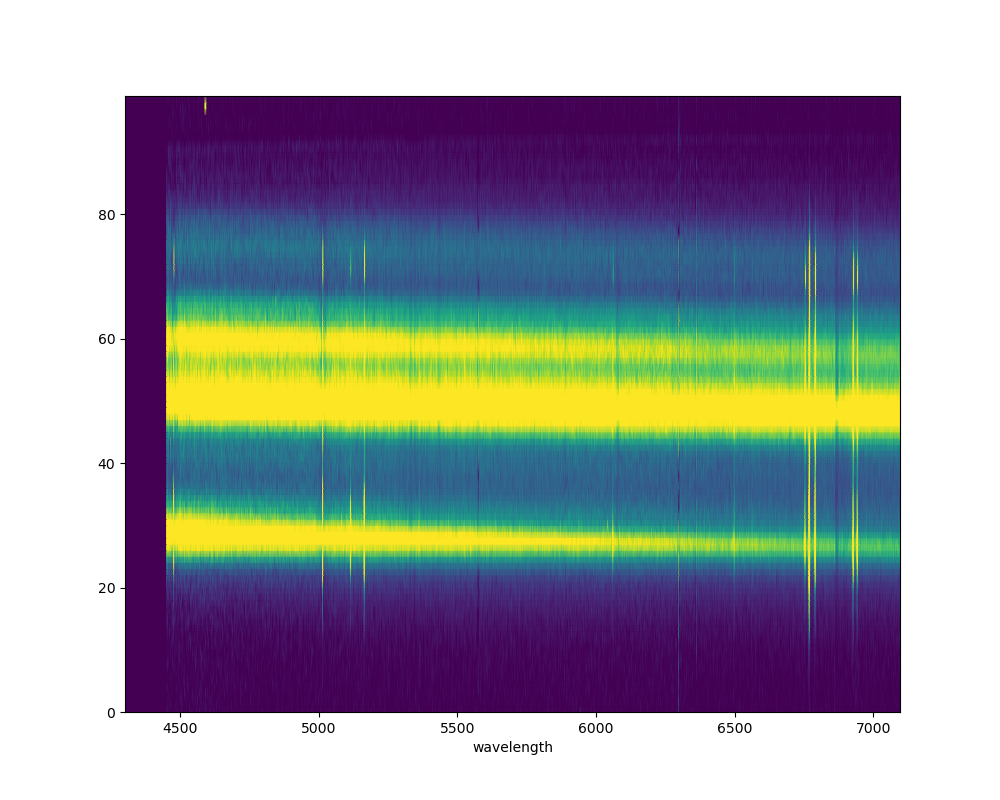

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.03191
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/PSF/Real_seeing_NGC3217_1.txt")
sigmas = seeing / 2.35
print(sigmas)

[0.82805206 0.93317351 0.82656693 0.81685935 0.93037569 0.84425532]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/NGC-3217_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     367   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        48   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

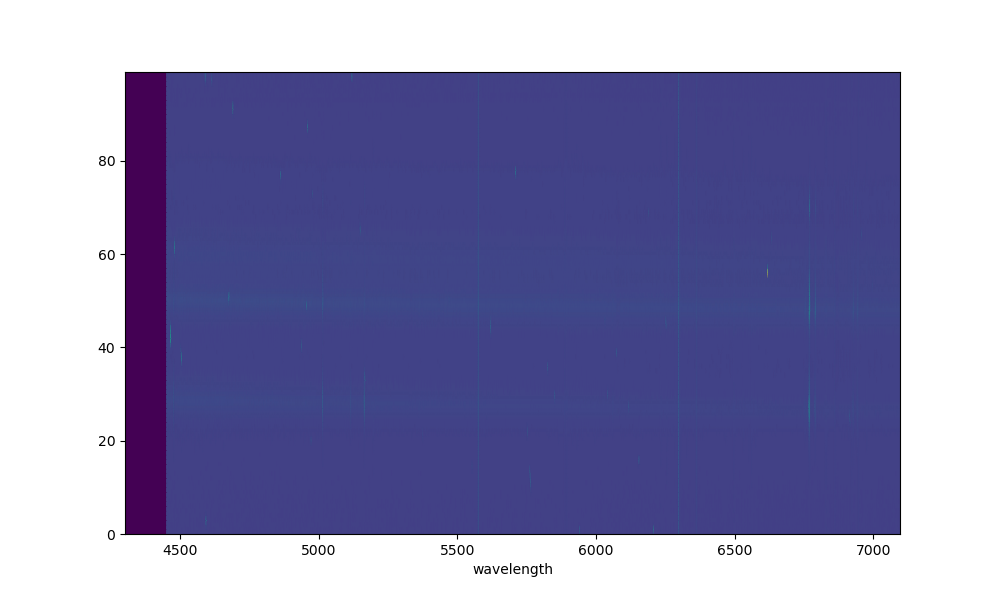

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/NGC-3217_1_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[67:167, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

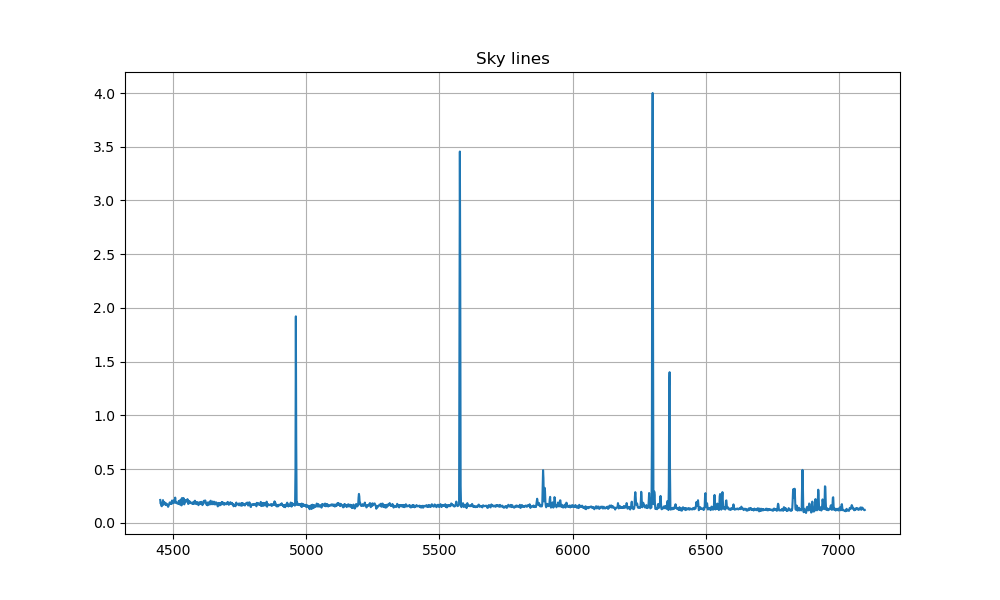

In [9]:
mask_sky = (y > 80)*(y < 90)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

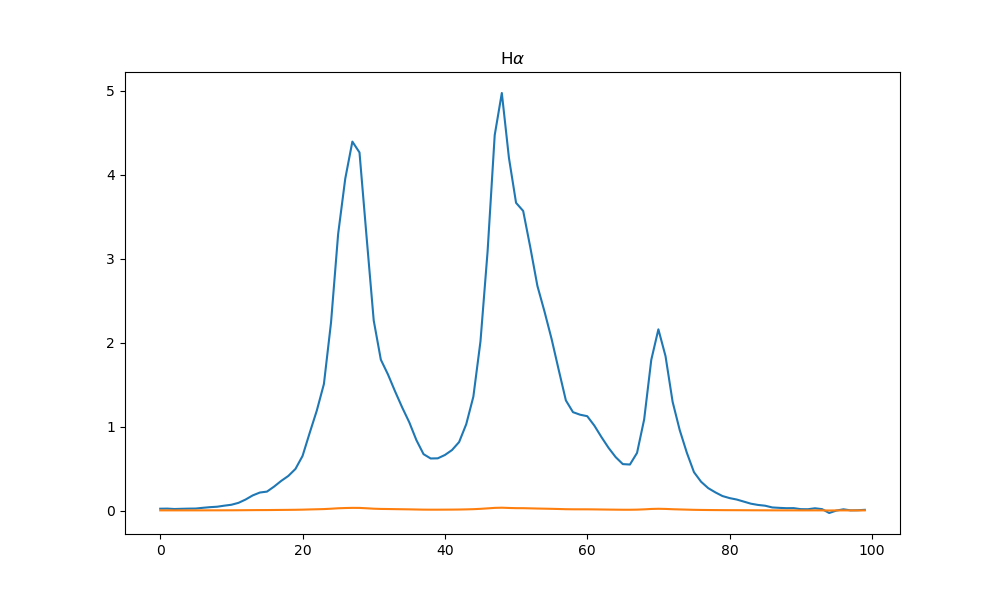

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_1/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [14]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])+
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 7)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 7)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 30),   # x_0: posizione da 0 a 100

    (0, 2),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (52, 58),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (58, 61),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (65, 75)   
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [15]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 740.4080523997901
differential_evolution step 2: f(x)= 719.135795955986
differential_evolution step 3: f(x)= 306.7298324808798
differential_evolution step 4: f(x)= 85.10681947497152
differential_evolution step 5: f(x)= 85.10681947497152
differential_evolution step 6: f(x)= 63.1009423492075
differential_evolution step 7: f(x)= 63.1009423492075
differential_evolution step 8: f(x)= 63.1009423492075
differential_evolution step 9: f(x)= 63.1009423492075
differential_evolution step 10: f(x)= 63.1009423492075
differential_evolution step 11: f(x)= 62.88879176802394
differential_evolution step 12: f(x)= 62.88879176802394
differential_evolution step 13: f(x)= 62.88879176802394
differential_evolution step 14: f(x)= 62.88879176802394
differential_evolution step 15: f(x)= 62.88879176802394
differential_evolution step 16: f(x)= 62.88879176802394
differential_evolution step 17: f(x)= 62.88879176802394
differential_evolution step 18: f(x)= 62.88879176802394
differe

Sérsic 1: I_e=0.8689, r_e=6.2799, n=1.0836, x_0=27.0995
Sérsic 2: I_e=1.2988, r_e=2.1243, n=0.7741, x_0=47.7150
Sérsic 3: I_e=0.3810, r_e=14.6094, n=1.2793, x_0=52.0031
Sérsic 4: I_e=0.1650, r_e=1.0815, n=0.4030, x_0=60.7765
Sérsic 5: I_e=0.3593, r_e=3.8137, n=1.2145, x_0=70.3050


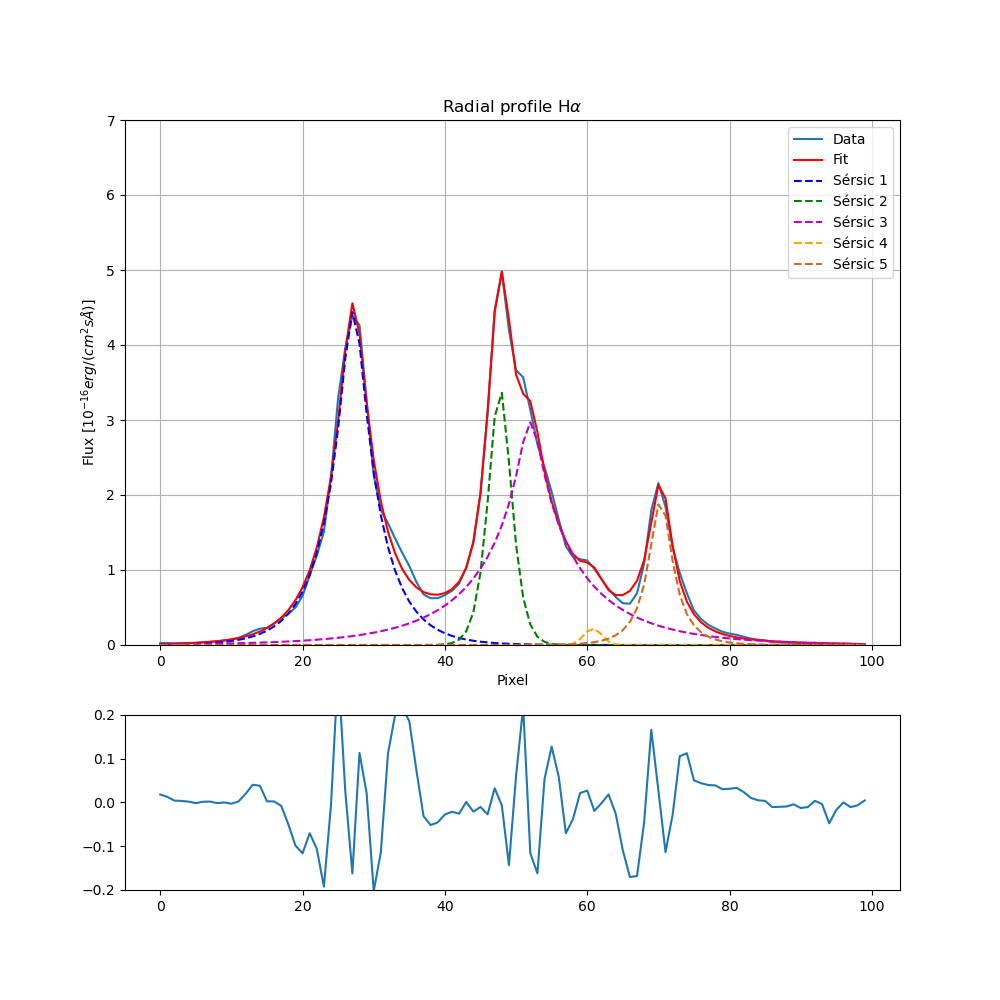

In [16]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [17]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)#, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6608\3444057438.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6608\3444057438.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.7852, r_e=7.0612, n=1.1524, x_0=27.3283
Sérsic 2: I_e=1.2360, r_e=1.5251, n=0.7284, x_0=47.4693
Sérsic 3: I_e=0.8466, r_e=7.9933, n=0.8863, x_0=50.9762
Sérsic 4: I_e=0.2775, r_e=1.7366, n=0.1232, x_0=60.8961
Sérsic 5: I_e=0.1632, r_e=8.5241, n=1.7724, x_0=70.3406
[0.0553787  0.29947691 0.05763245 0.06845657 0.48537056 0.43159819
 0.34287932 0.1330456  0.15500302 0.85859605 0.09352693 0.32656801
 0.21578377 3.58659948 0.79242824 0.30370416 0.04006832 1.37438708
 0.19075635 0.07481732]
1.7316782371276909


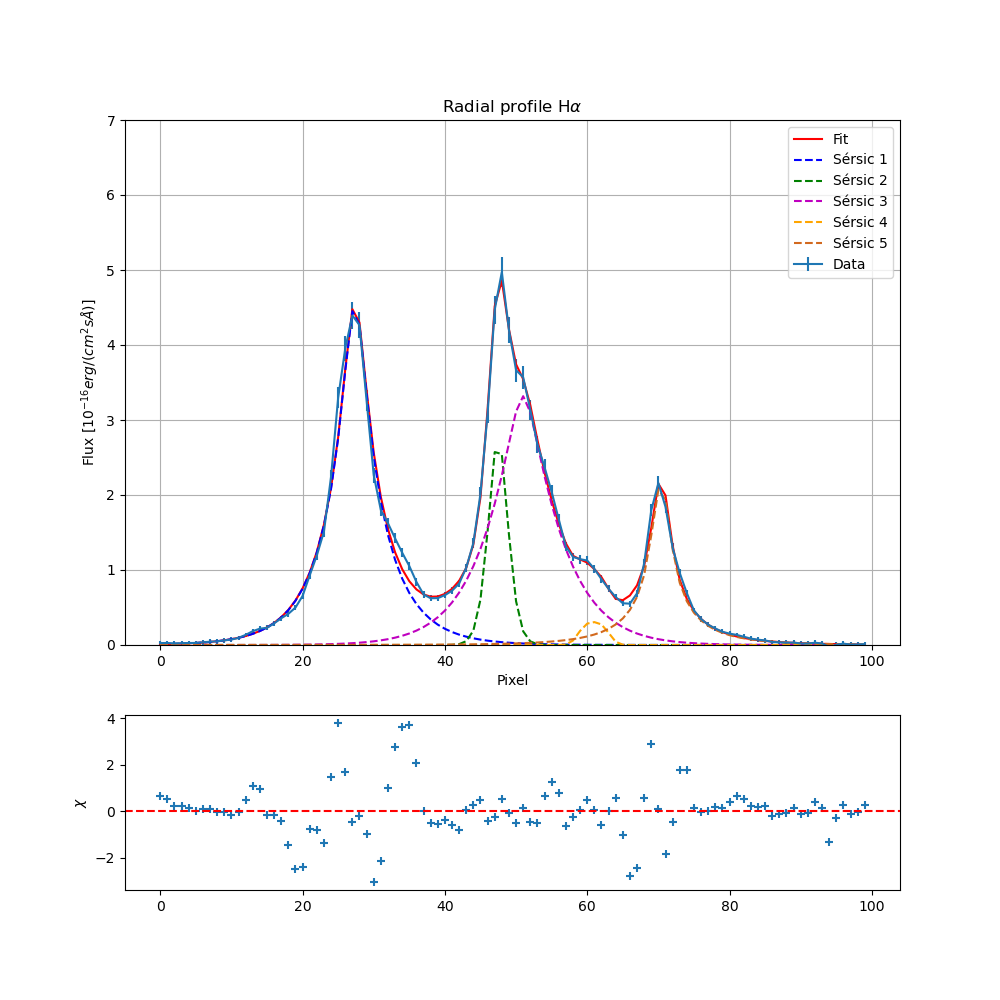

In [18]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [46]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 10),
    (0, 10),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 10),
    (0, 3),
    (0.1, 10),
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),

    (0, 20),
    (0, 7),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 10),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

bounds_OIII = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (27, 29),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 3),
    (0.1, 10),
    (48, 50),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (51, 53),

    (0, 20),
    (0, 7),
    (0.1, 10),
    (58, 60),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (71, 73),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

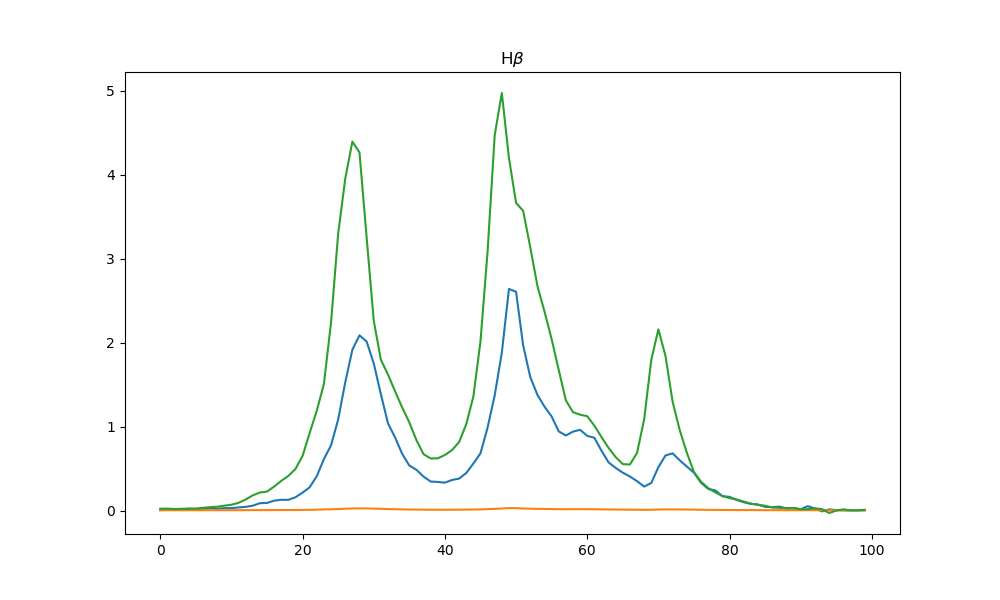

In [20]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'H$\beta$')

In [21]:
# Bounds:
bounds = bounds_OIII

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1552.450340304548
differential_evolution step 2: f(x)= 1552.450340304548
differential_evolution step 3: f(x)= 1046.2435472772875
differential_evolution step 4: f(x)= 990.5356588263536
differential_evolution step 5: f(x)= 990.5356588263536
differential_evolution step 6: f(x)= 556.4394337217963
differential_evolution step 7: f(x)= 113.04680756292734
differential_evolution step 8: f(x)= 113.04680756292734
differential_evolution step 9: f(x)= 82.04823305292713
differential_evolution step 10: f(x)= 82.04823305292713
differential_evolution step 11: f(x)= 56.63932769824646
differential_evolution step 12: f(x)= 56.63932769824646
differential_evolution step 13: f(x)= 52.84370366452789
differential_evolution step 14: f(x)= 52.84370366452789
differential_evolution step 15: f(x)= 41.77042720000143
differential_evolution step 16: f(x)= 41.77042720000143
differential_evolution step 17: f(x)= 41.77042720000143
differential_evolution step 18: f(x)= 36.6460966254570

Sérsic 1: I_e=0.3665, r_e=8.1946, n=1.1723, x_0=28.4601
Sérsic 2: I_e=0.7314, r_e=3.0000, n=0.8047, x_0=49.0107
Sérsic 3: I_e=0.4463, r_e=2.9178, n=0.1000, x_0=52.3542
Sérsic 4: I_e=0.2796, r_e=7.0000, n=0.8224, x_0=58.9777
Sérsic 5: I_e=0.1867, r_e=5.0000, n=0.8116, x_0=72.7414


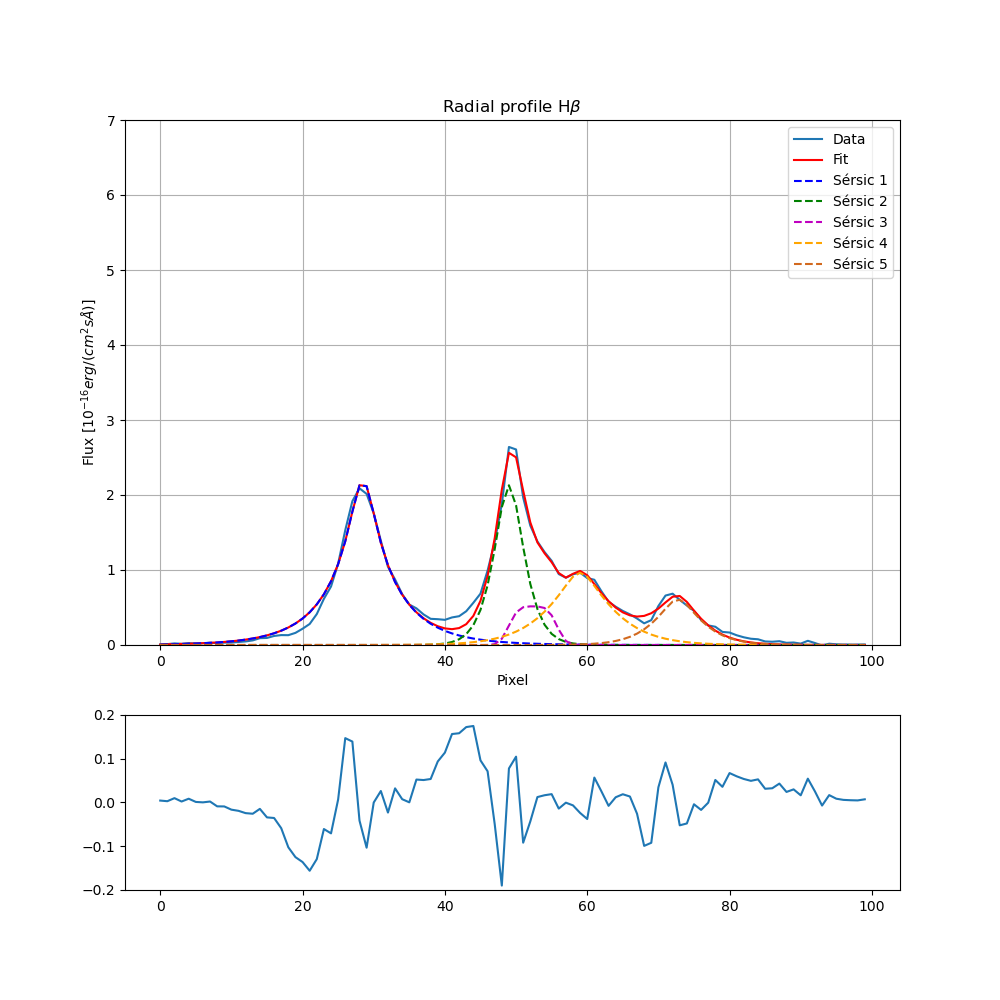

In [22]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [26]:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (27, 29),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 10),
    (0.1, 10),
    (48, 50),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (51, 53),

    (0, 20),
    (0, 10),
    (0.1, 10),
    (58, 60),

    (0, 20),
    (0, 10),
    (0.1, 10),
    (71, 73),
]
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.5107, r_e=5.8398, n=0.9695, x_0=28.4444
Sérsic 2: I_e=0.1948, r_e=10.0000, n=1.7107, x_0=49.2095
Sérsic 3: I_e=0.3793, r_e=2.6737, n=0.1000, x_0=52.2684
Sérsic 4: I_e=0.3612, r_e=4.0016, n=0.4922, x_0=59.3681
Sérsic 5: I_e=0.0952, r_e=9.5853, n=1.2593, x_0=72.2885
[0.03569475 0.34491184 0.05318793 0.05600294 0.10526197 3.6180702
 0.52984413 0.09555097 0.33728566 2.8563278  0.29357645 1.45541682
 0.05127926 0.36768512 0.09496705 0.30340728 0.01938768 1.5561852
 0.14337183 0.13186919]
0.6701819318656405


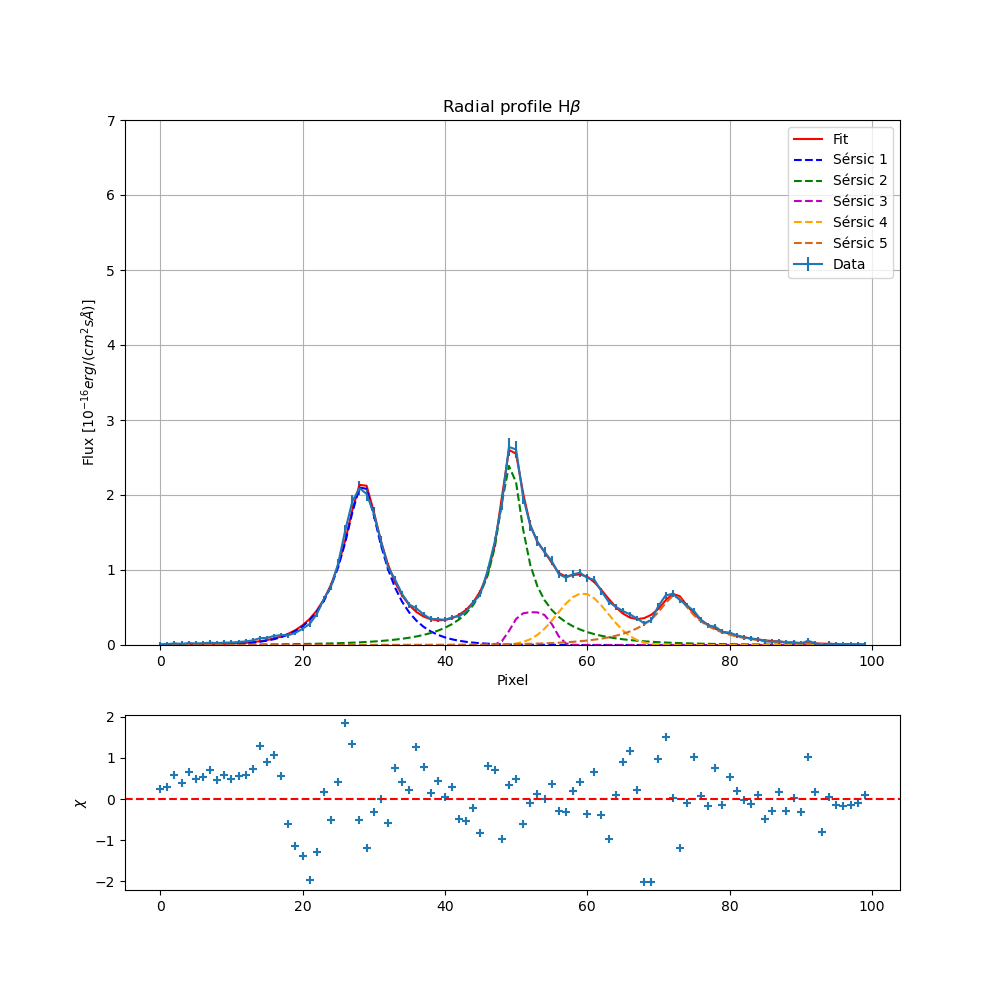

In [27]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

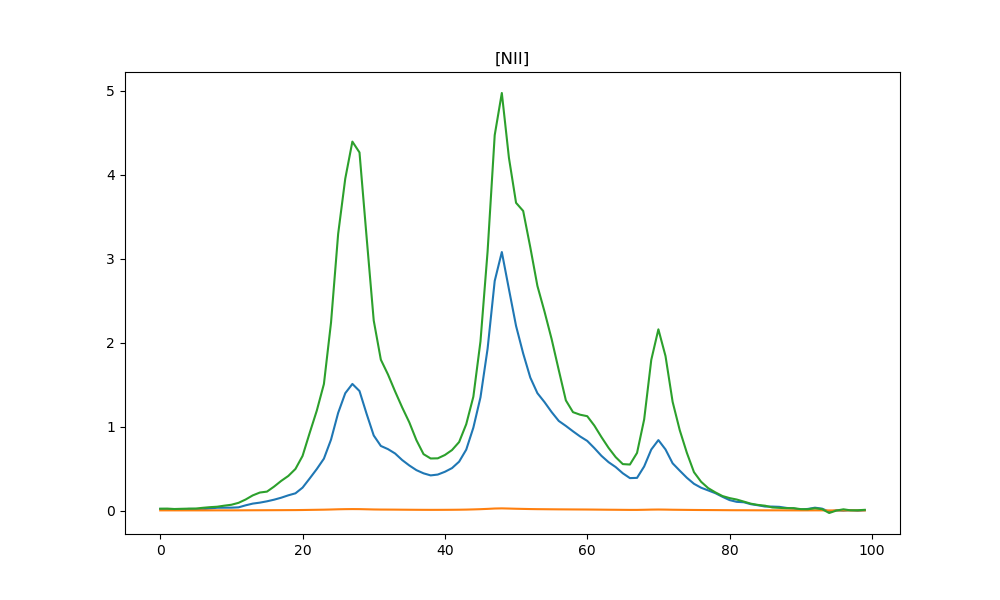

In [28]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'[NII]')

In [29]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3078.317401021764
differential_evolution step 2: f(x)= 1673.2890010956705
differential_evolution step 3: f(x)= 395.68889210843673
differential_evolution step 4: f(x)= 307.6910999939954
differential_evolution step 5: f(x)= 159.95930111246935
differential_evolution step 6: f(x)= 50.869776709091305
differential_evolution step 7: f(x)= 50.869776709091305
differential_evolution step 8: f(x)= 50.869776709091305
differential_evolution step 9: f(x)= 50.869776709091305
differential_evolution step 10: f(x)= 50.869776709091305
differential_evolution step 11: f(x)= 50.869776709091305
differential_evolution step 12: f(x)= 50.869776709091305
differential_evolution step 13: f(x)= 50.869776709091305
differential_evolution step 14: f(x)= 33.30628612599063
differential_evolution step 15: f(x)= 33.30628612599063
differential_evolution step 16: f(x)= 33.30628612599063
differential_evolution step 17: f(x)= 33.30628612599063
differential_evolution step 18: f(x)= 33.30628

Sérsic 1: I_e=0.2717, r_e=10.0000, n=1.0805, x_0=27.5323
Sérsic 2: I_e=0.8837, r_e=3.0000, n=0.7590, x_0=47.3150
Sérsic 3: I_e=0.9590, r_e=3.0000, n=0.2342, x_0=51.9682
Sérsic 4: I_e=0.5914, r_e=3.1478, n=0.2802, x_0=59.9041
Sérsic 5: I_e=0.2498, r_e=5.0000, n=0.7838, x_0=70.4358


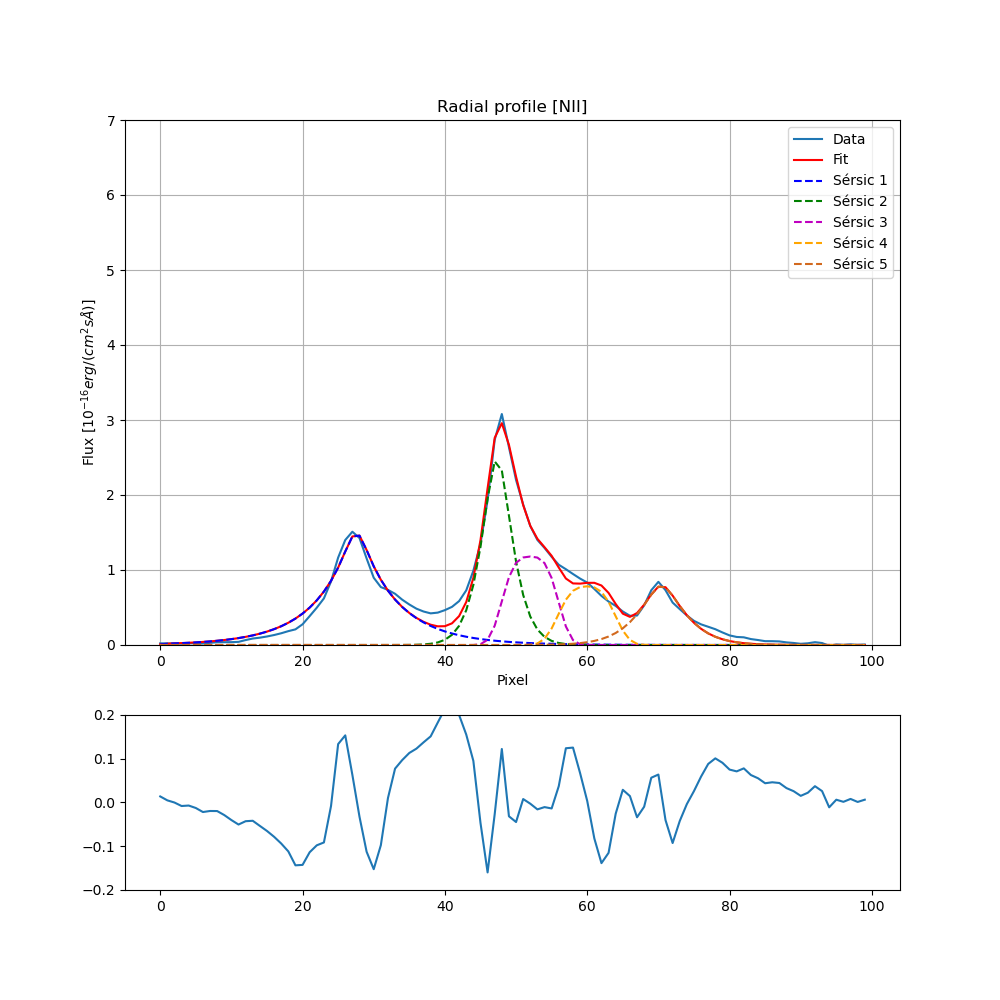

In [30]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [39]:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 20),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 10),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),

    (0, 20),
    (0, 7),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 20),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.3112, r_e=7.3610, n=1.0082, x_0=27.3361
Sérsic 2: I_e=0.2362, r_e=9.9997, n=1.6246, x_0=47.6557
Sérsic 3: I_e=0.6147, r_e=3.0000, n=0.2732, x_0=51.9682
Sérsic 4: I_e=0.4057, r_e=2.9737, n=0.2916, x_0=59.9041
Sérsic 5: I_e=0.0809, r_e=12.1846, n=1.4523, x_0=70.2993
[0.03127101 0.79591979 0.0762525  0.09949572 0.18486605 5.38288658
 0.97833613 0.11409288 0.10520871 2.89109492 0.10106529 1.45148244
 0.1839246  1.93997278 0.279572   3.19161052 0.02050177 2.79939181
 0.18067855 0.1278291 ]
1.08301417132296


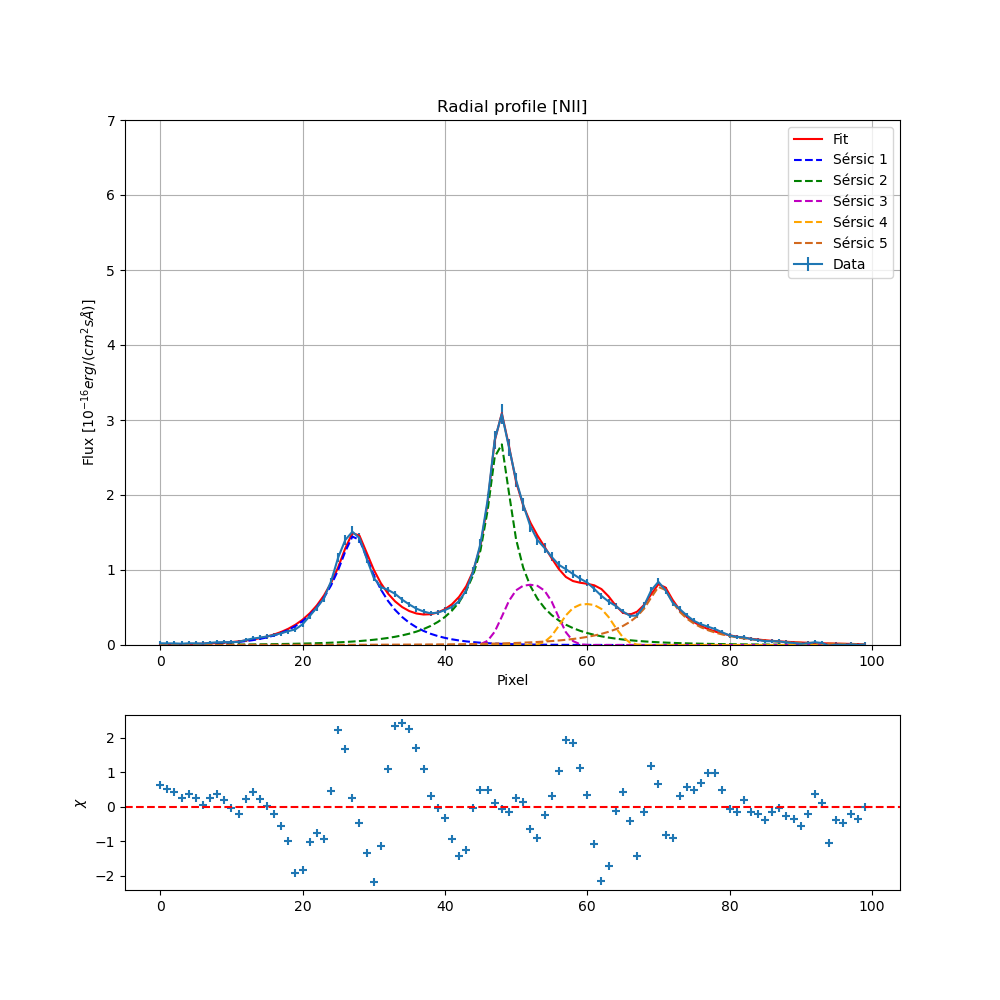

In [40]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6608\283383152.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Text(0.5, 1.0, '[SII]')

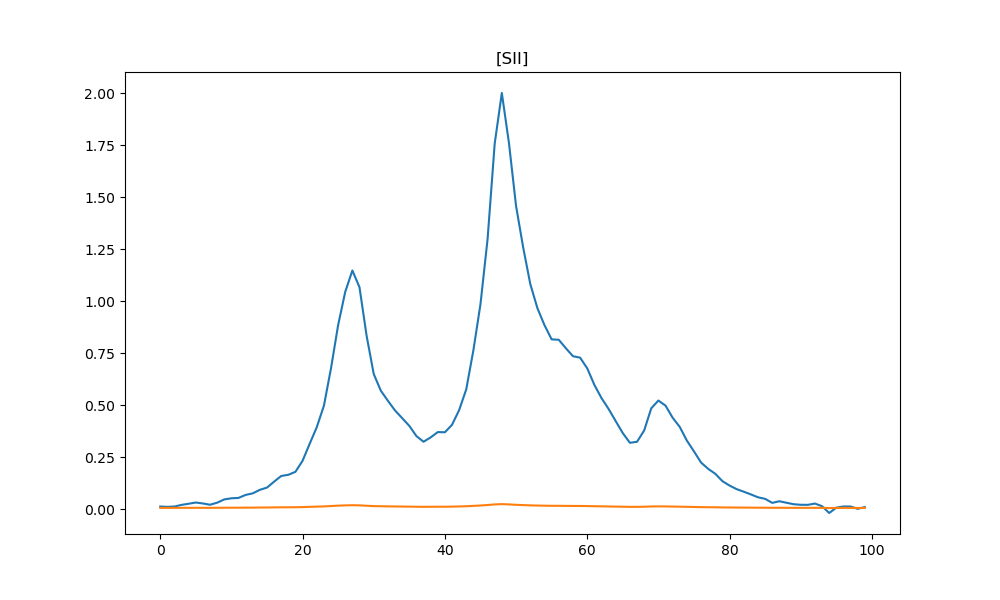

In [41]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [47]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 4843.830075605505
differential_evolution step 2: f(x)= 2938.591265752899
differential_evolution step 3: f(x)= 1169.0113286556998
differential_evolution step 4: f(x)= 898.5165037084588
differential_evolution step 5: f(x)= 898.5165037084588
differential_evolution step 6: f(x)= 898.5165037084588
differential_evolution step 7: f(x)= 898.5165037084588
differential_evolution step 8: f(x)= 898.5165037084588
differential_evolution step 9: f(x)= 748.9832496004518
differential_evolution step 10: f(x)= 103.08021235487682
differential_evolution step 11: f(x)= 103.08021235487682
differential_evolution step 12: f(x)= 103.08021235487682
differential_evolution step 13: f(x)= 103.08021235487682
differential_evolution step 14: f(x)= 103.08021235487682
differential_evolution step 15: f(x)= 103.08021235487682
differential_evolution step 16: f(x)= 77.52126935646203
differential_evolution step 17: f(x)= 77.52126935646203
differential_evolution step 18: f(x)= 77.521269356

Sérsic 1: I_e=0.1899, r_e=8.6441, n=1.1473, x_0=27.0103
Sérsic 2: I_e=0.1944, r_e=10.0000, n=1.4342, x_0=47.7001
Sérsic 3: I_e=0.3470, r_e=3.0000, n=0.2620, x_0=51.9682
Sérsic 4: I_e=0.3341, r_e=3.1479, n=0.2900, x_0=59.9041
Sérsic 5: I_e=0.0900, r_e=9.9736, n=1.0954, x_0=70.6857


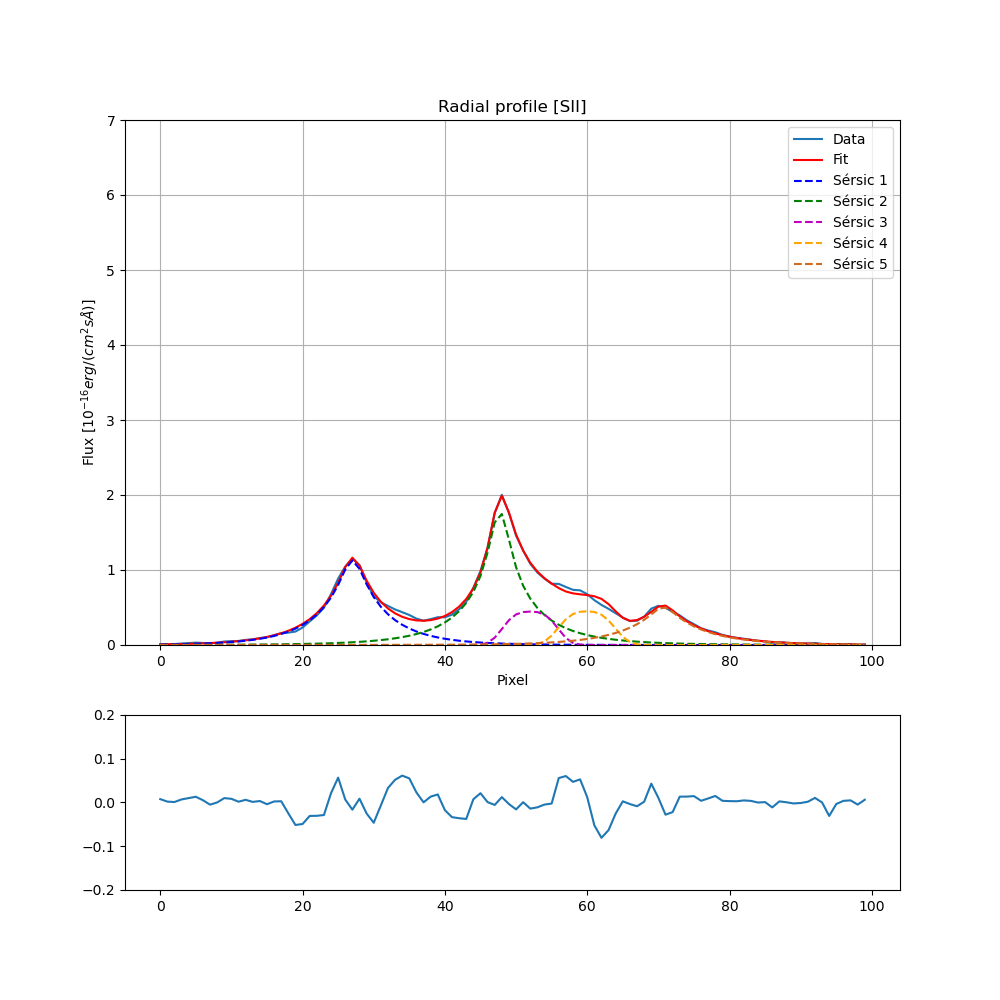

In [48]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [49]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1852, r_e=8.7670, n=1.1646, x_0=27.0703
Sérsic 2: I_e=0.1934, r_e=10.0000, n=1.4332, x_0=47.7011
Sérsic 3: I_e=0.3543, r_e=3.0000, n=0.2641, x_0=51.9682
Sérsic 4: I_e=0.3221, r_e=3.1106, n=0.3072, x_0=59.9041
Sérsic 5: I_e=0.0928, r_e=9.8990, n=1.0725, x_0=70.6780
[0.01713661 0.66070557 0.06625565 0.0709886  0.0456748  1.79506708
 0.29191339 0.2017712  0.09464525 1.50674964 0.11399938 2.04001237
 0.08557954 0.91833843 0.16115891 1.54585218 0.01520228 1.20990902
 0.1104423  0.15559883]
0.5229620846887916


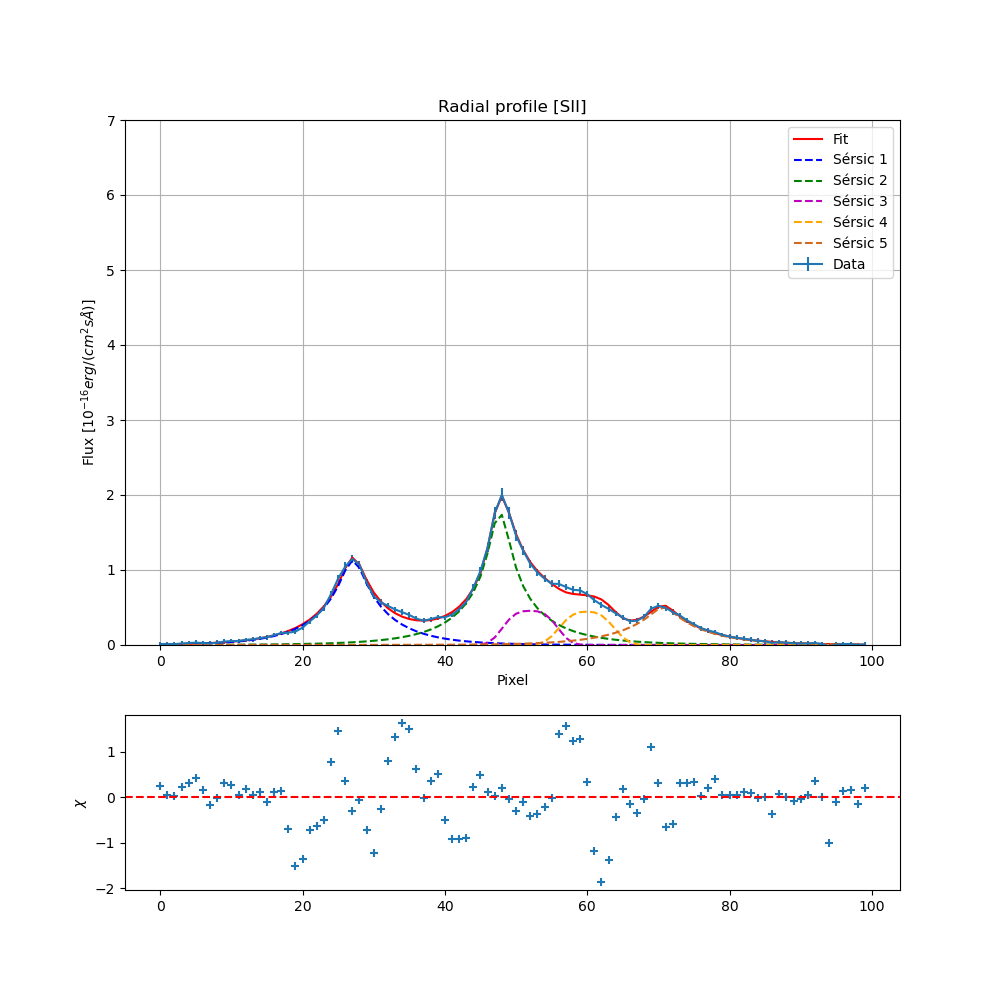

In [50]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

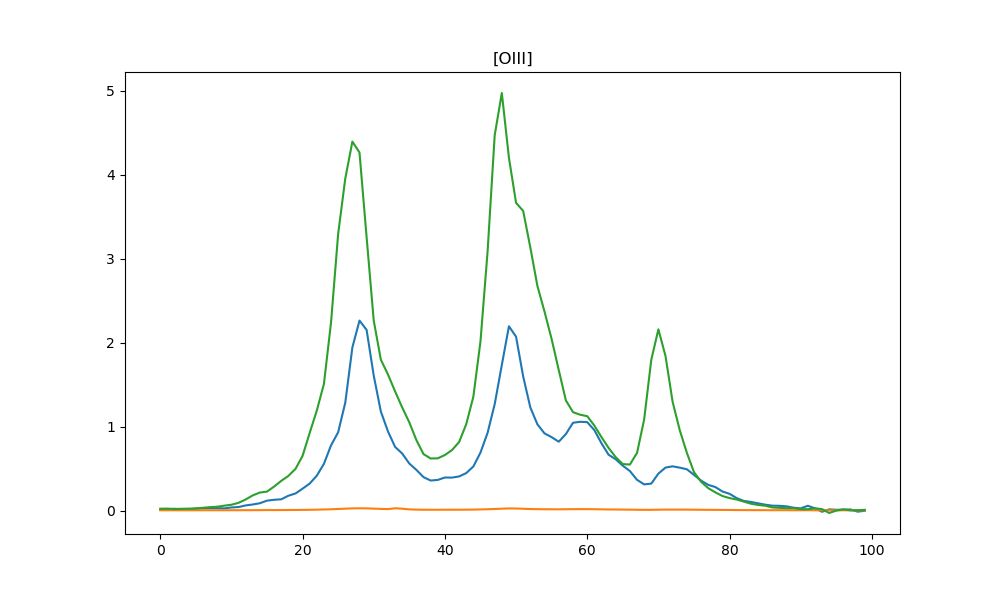

In [51]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.plot(x_axes, radial_profile_HA)
plt.title(r'[OIII]')

In [52]:
# Bounds:
bounds = bounds_OIII
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3149.966725240456
differential_evolution step 2: f(x)= 384.17283927380777
differential_evolution step 3: f(x)= 319.99099224606425
differential_evolution step 4: f(x)= 55.41247571493695
differential_evolution step 5: f(x)= 55.41247571493695
differential_evolution step 6: f(x)= 51.831509380556184
differential_evolution step 7: f(x)= 51.831509380556184
differential_evolution step 8: f(x)= 51.831509380556184
differential_evolution step 9: f(x)= 51.831509380556184
differential_evolution step 10: f(x)= 51.831509380556184
differential_evolution step 11: f(x)= 51.831509380556184
differential_evolution step 12: f(x)= 22.86389061191428
differential_evolution step 13: f(x)= 22.86389061191428
differential_evolution step 14: f(x)= 22.86389061191428
differential_evolution step 15: f(x)= 14.258089096000782
differential_evolution step 16: f(x)= 14.258089096000782
differential_evolution step 17: f(x)= 14.258089096000782
differential_evolution step 18: f(x)= 14.25808

Sérsic 1: I_e=0.2486, r_e=10.0000, n=1.4666, x_0=28.3706
Sérsic 2: I_e=0.7191, r_e=3.0000, n=0.7452, x_0=49.0712
Sérsic 3: I_e=0.0387, r_e=2.9987, n=0.9993, x_0=52.9985
Sérsic 4: I_e=0.3120, r_e=7.0000, n=0.8209, x_0=59.1737
Sérsic 5: I_e=0.1989, r_e=5.0000, n=0.6063, x_0=73.0000


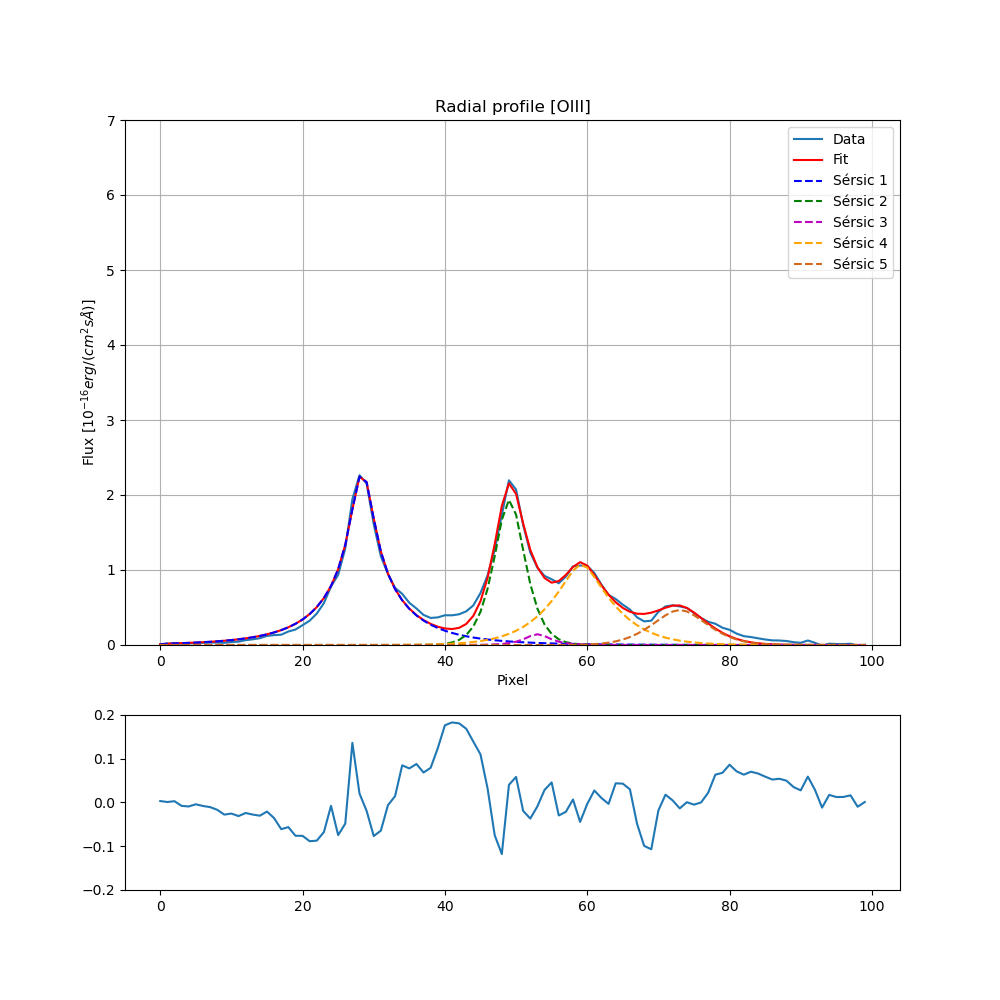

In [53]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [57]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6608\3444057438.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6608\3444057438.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_6608\3444057438.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Optimize parameters with curve fit:
Sérsic 1: I_e=0.3036, r_e=7.6336, n=1.3456, x_0=28.3458
Sérsic 2: I_e=0.1281, r_e=13.1815, n=1.9018, x_0=49.1549
Sérsic 3: I_e=0.0777, r_e=2.3900, n=0.0468, x_0=52.1172
Sérsic 4: I_e=0.3645, r_e=4.2954, n=0.5779, x_0=59.6229
Sérsic 5: I_e=0.1141, r_e=9.0379, n=0.9525, x_0=72.9405
[ 0.02665422  0.55929478  0.06582446  0.04220515  0.04397477  3.64528248
  0.35564523  0.37943378  7.54622464 10.08471071  2.55126231  4.06776835
  0.04602582  0.40480807  0.08053731  0.15300358  0.01695717  1.04798828
  0.10012142  0.20736026]
0.47904045413796786


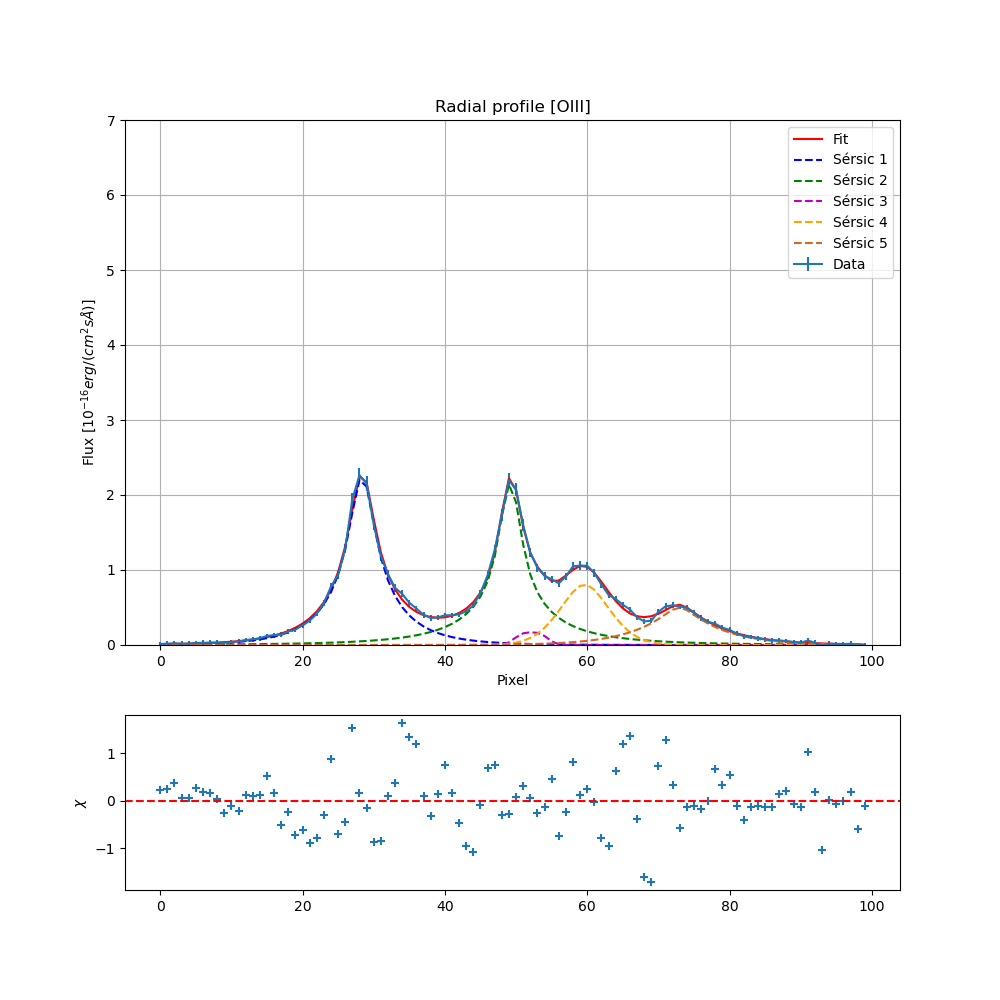

In [58]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [59]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

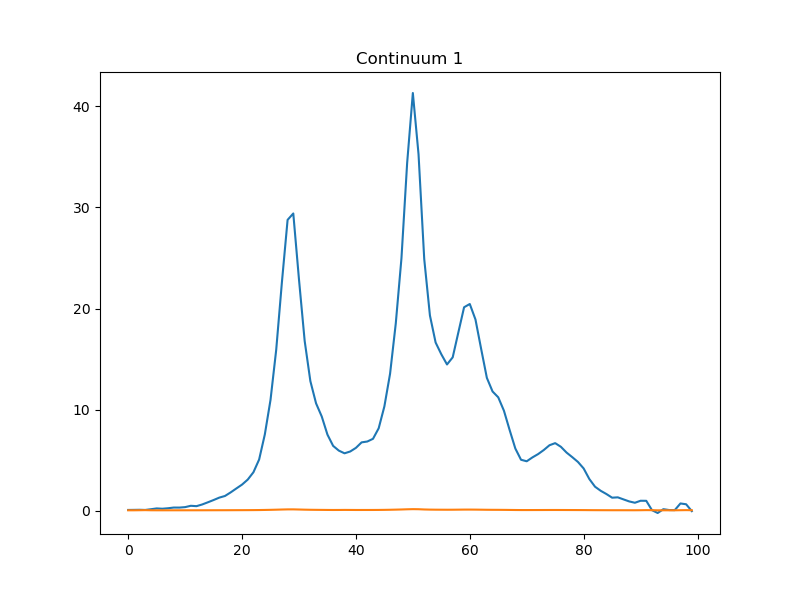

In [93]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [94]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3895.997640134038
differential_evolution step 2: f(x)= 3895.997640134038
differential_evolution step 3: f(x)= 2867.866500030307
differential_evolution step 4: f(x)= 2867.866500030307
differential_evolution step 5: f(x)= 2867.1922119601327
differential_evolution step 6: f(x)= 2867.1922119601327
differential_evolution step 7: f(x)= 1523.9013283098523
differential_evolution step 8: f(x)= 1523.9013283098523
differential_evolution step 9: f(x)= 1523.9013283098523
differential_evolution step 10: f(x)= 1318.5872935417729
differential_evolution step 11: f(x)= 1318.5872935417729
differential_evolution step 12: f(x)= 1318.5872935417729
differential_evolution step 13: f(x)= 1318.5872935417729
differential_evolution step 14: f(x)= 1318.5872935417729
differential_evolution step 15: f(x)= 1318.5872935417729
differential_evolution step 16: f(x)= 1137.4712457216785
differential_evolution step 17: f(x)= 1137.4712457216785
differential_evolution step 18: f(x)= 1137.4

In [95]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=1.0000, r_e=18.2896, n=2.3629, x_0=28.5785
Sérsic 2: I_e=2.0000, r_e=11.7655, n=2.0075, x_0=49.9492
Sérsic 3: I_e=1.0000, r_e=9.0871, n=0.1000, x_0=56.7802
Sérsic 4: I_e=1.0000, r_e=21.9776, n=1.7953, x_0=60.0942
Sérsic 5: I_e=1.0000, r_e=7.8523, n=0.9560, x_0=75.0000


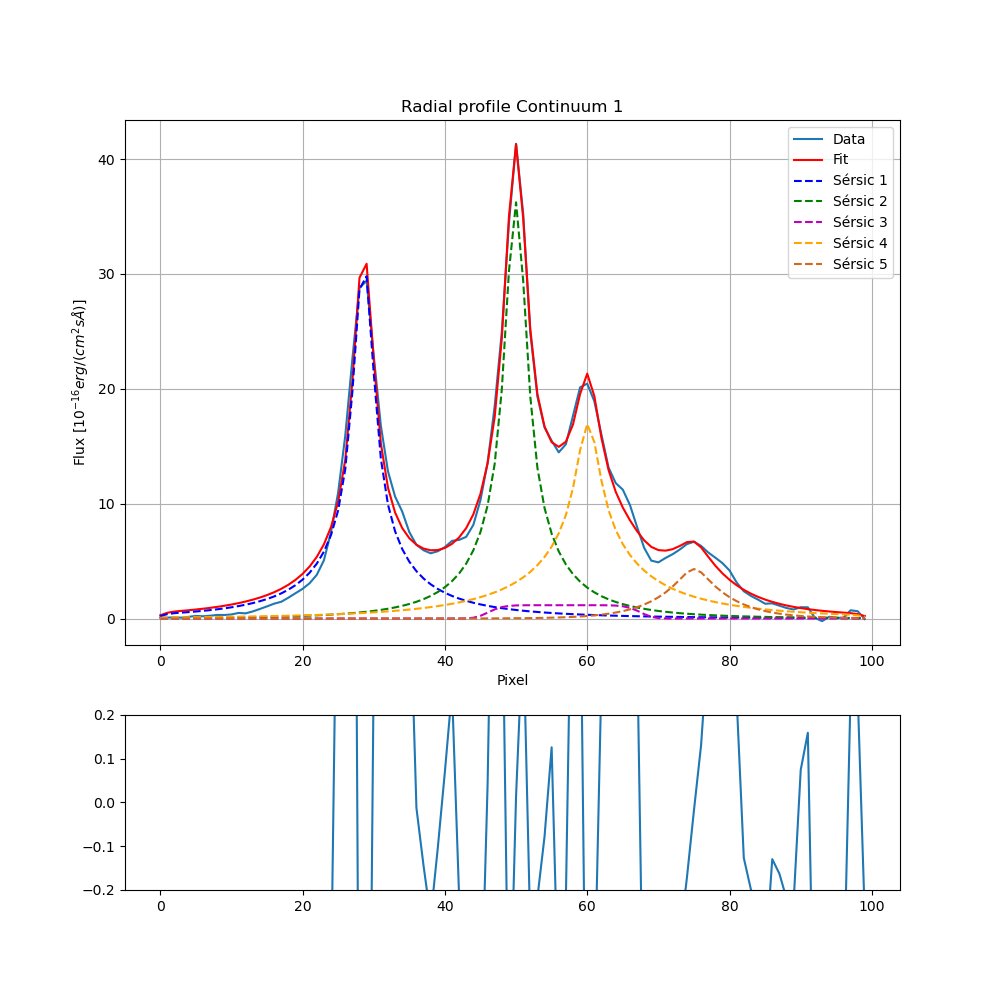

In [96]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [97]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.0000, r_e=12.6602, n=2.6791, x_0=28.7525
Sérsic 2: I_e=2.0000, r_e=14.2965, n=1.9472, x_0=49.9332
Sérsic 3: I_e=1.0000, r_e=8.7971, n=0.1000, x_0=57.7252
Sérsic 4: I_e=1.0000, r_e=14.9220, n=1.8772, x_0=60.3245
Sérsic 5: I_e=1.0000, r_e=8.5718, n=1.0888, x_0=75.0000
[ 1.17145042 11.51445485  0.92597615  0.16529408  3.78728928 21.72052995
  1.67025993  0.23857244  5.63397904 24.75534425  0.74245069  7.73670011
  2.07176431 27.7297813   1.39113165  0.37856735  0.68095085  6.04020684
  0.49800651  0.71145224]
20.537509247945945


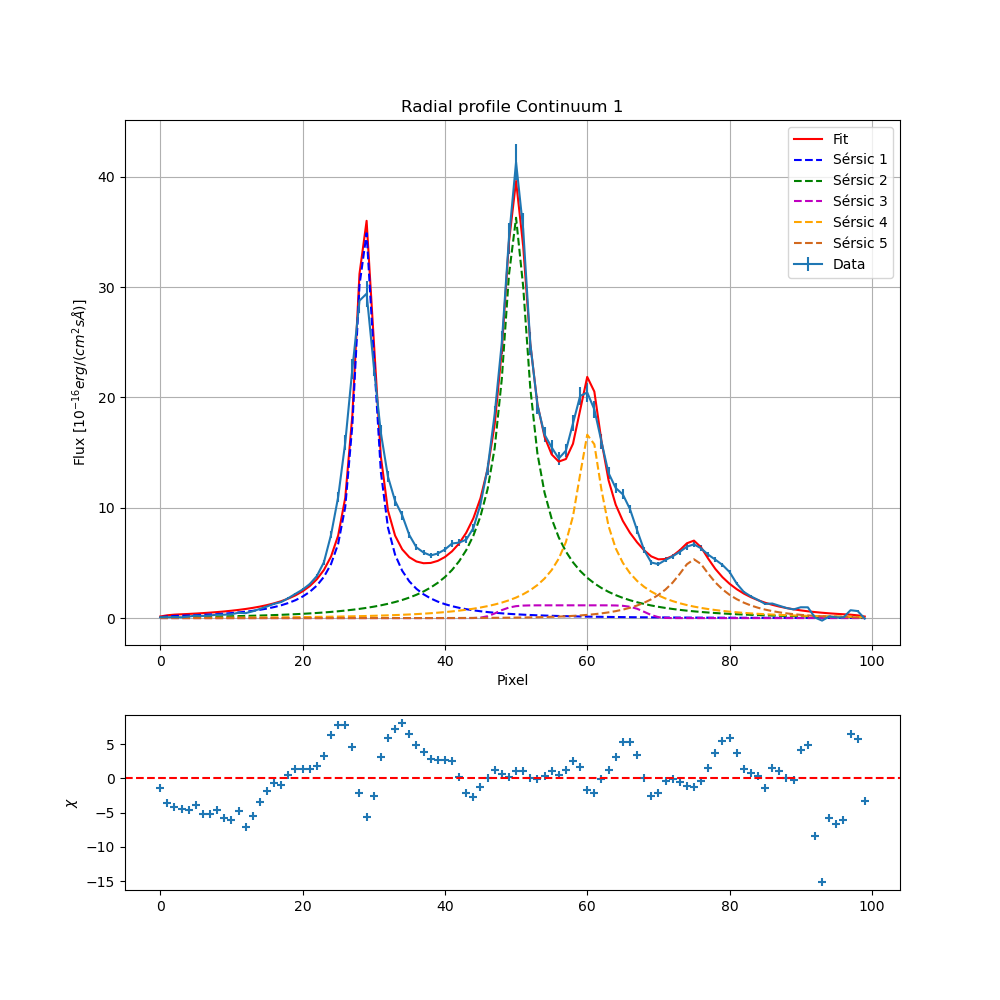

In [98]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

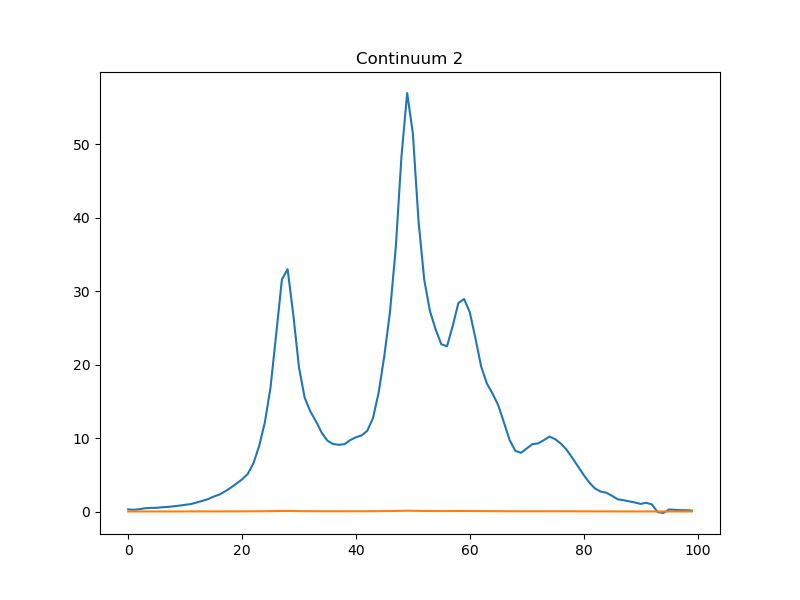

In [99]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [100]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 8457.107121410325
differential_evolution step 2: f(x)= 7220.19792762033
differential_evolution step 3: f(x)= 7220.19792762033
differential_evolution step 4: f(x)= 6767.679670207834
differential_evolution step 5: f(x)= 4631.195571979439
differential_evolution step 6: f(x)= 3887.3796156318676
differential_evolution step 7: f(x)= 2803.65214029915
differential_evolution step 8: f(x)= 2471.276598563623
differential_evolution step 9: f(x)= 2471.276598563623
differential_evolution step 10: f(x)= 2092.597206398485
differential_evolution step 11: f(x)= 2092.597206398485
differential_evolution step 12: f(x)= 2092.597206398485
differential_evolution step 13: f(x)= 2092.597206398485
differential_evolution step 14: f(x)= 1992.471976677485
differential_evolution step 15: f(x)= 1992.471976677485
differential_evolution step 16: f(x)= 1992.471976677485
differential_evolution step 17: f(x)= 1992.471976677485
differential_evolution step 18: f(x)= 1992.471976677485
dif

Sérsic 1: I_e=1.0000, r_e=19.8680, n=2.3757, x_0=27.6662
Sérsic 2: I_e=2.0000, r_e=15.8934, n=2.1487, x_0=48.9827
Sérsic 3: I_e=1.0000, r_e=15.1234, n=1.2055, x_0=52.0000
Sérsic 4: I_e=1.0000, r_e=30.1216, n=1.9586, x_0=59.4248
Sérsic 5: I_e=1.0000, r_e=8.6497, n=1.2014, x_0=74.8512


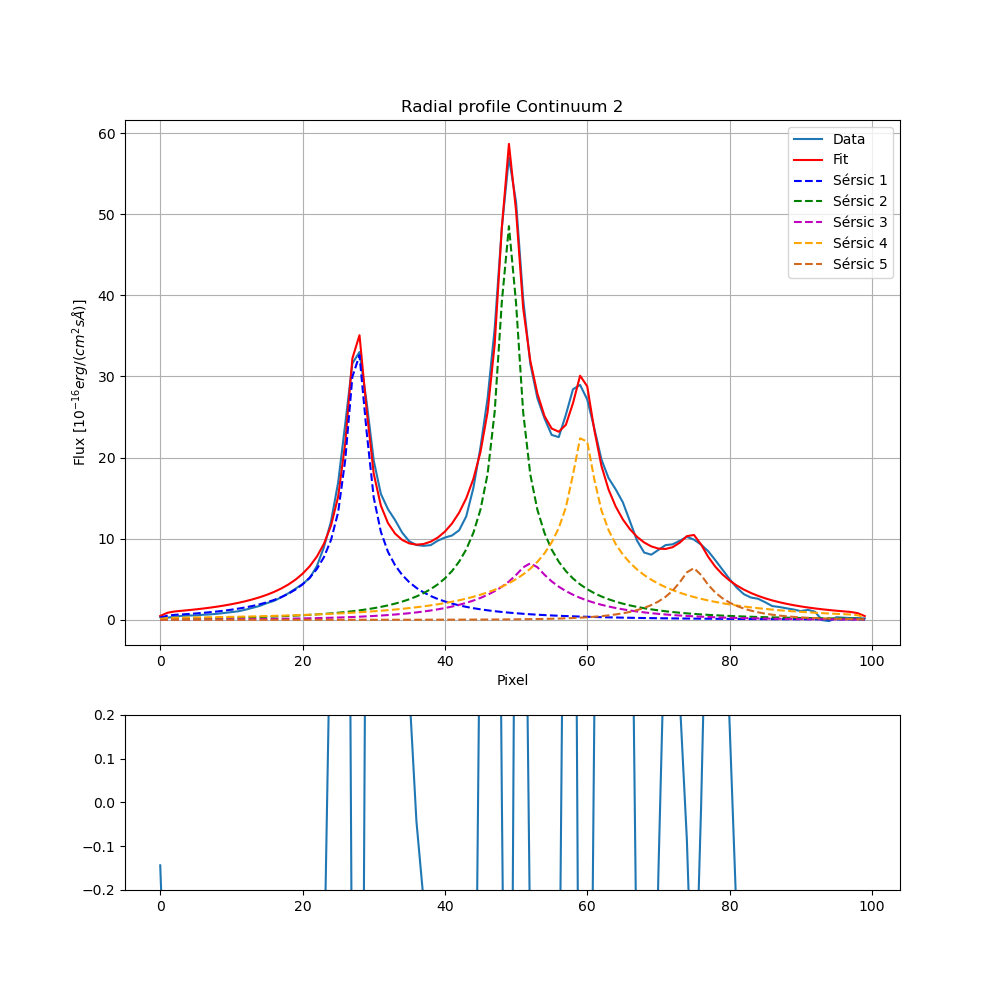

In [101]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [102]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.0000, r_e=14.2654, n=2.6166, x_0=27.7898
Sérsic 2: I_e=2.0000, r_e=18.4340, n=2.2920, x_0=49.1561
Sérsic 3: I_e=1.0000, r_e=28.2937, n=0.1000, x_0=52.1735
Sérsic 4: I_e=1.0000, r_e=18.2410, n=2.2012, x_0=59.5522
Sérsic 5: I_e=1.0000, r_e=7.7585, n=1.3178, x_0=74.4871
[ 1.54568897 16.67409533  1.18251083  0.17778759  3.35494425 28.68240551
  1.17070412  0.21420219  1.67925851 15.69339491  0.12137297  2.63114823
  2.64222418 46.0276746   1.78988466  0.3064017   1.63300429 13.23149701
  1.1300527   0.47975761]
19.33979534712714


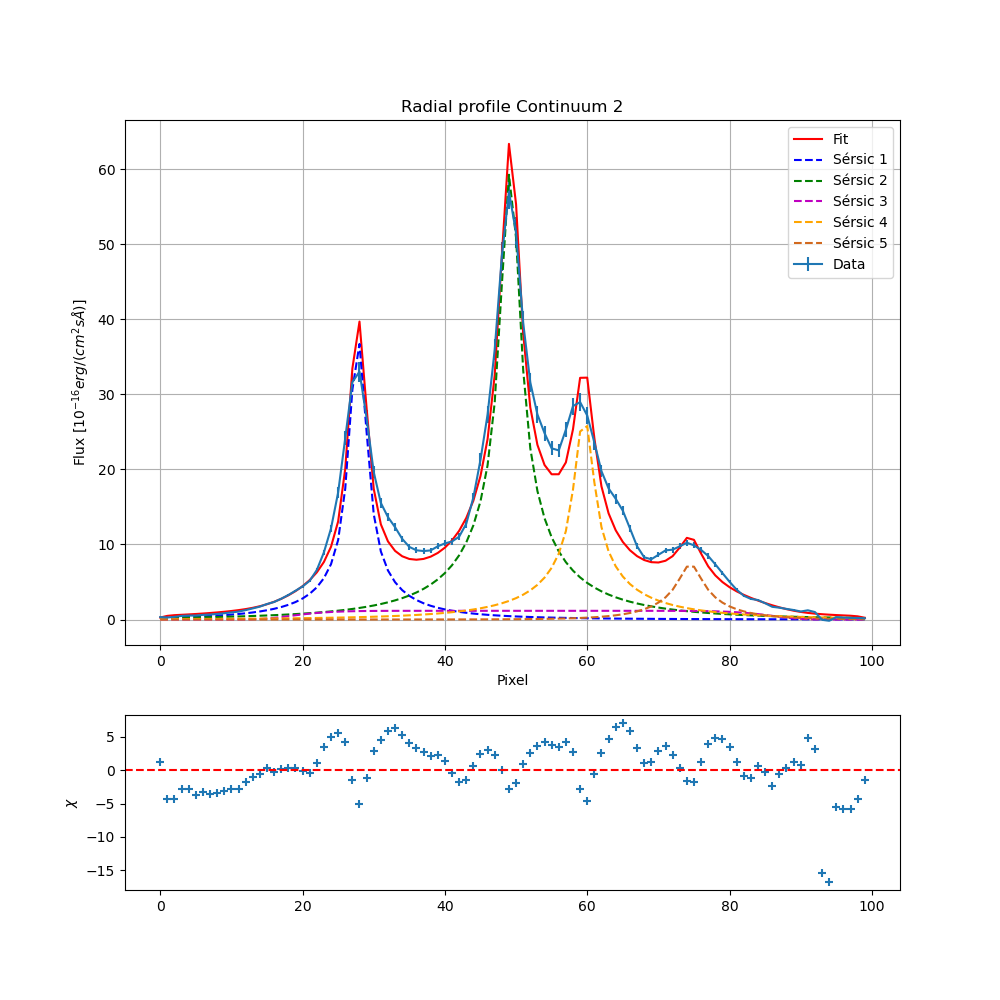

In [103]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

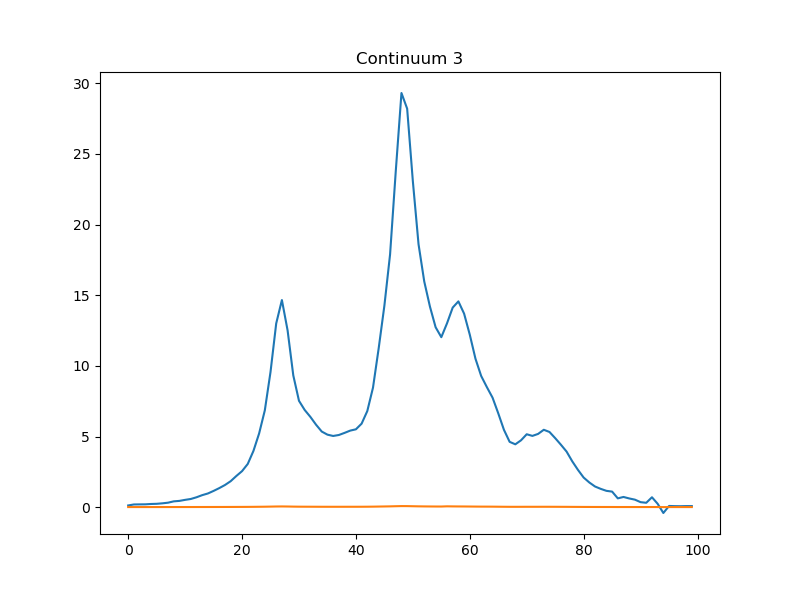

In [104]:
mask_continuum_3 = (wv > 6400)*(wv < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [105]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2038.8082390891454
differential_evolution step 2: f(x)= 2038.8082390891454
differential_evolution step 3: f(x)= 1289.008138811604
differential_evolution step 4: f(x)= 1125.1811188964386
differential_evolution step 5: f(x)= 960.3061175140627
differential_evolution step 6: f(x)= 682.5934798446713
differential_evolution step 7: f(x)= 682.5934798446713
differential_evolution step 8: f(x)= 682.5934798446713
differential_evolution step 9: f(x)= 682.5934798446713
differential_evolution step 10: f(x)= 682.5934798446713
differential_evolution step 11: f(x)= 682.5934798446713
differential_evolution step 12: f(x)= 579.2889589986085
differential_evolution step 13: f(x)= 579.2889589986085
differential_evolution step 14: f(x)= 579.2889589986085
differential_evolution step 15: f(x)= 579.2889589986085
differential_evolution step 16: f(x)= 579.2889589986085
differential_evolution step 17: f(x)= 435.37444518793694
differential_evolution step 18: f(x)= 317.29124295420

Sérsic 1: I_e=1.0000, r_e=12.5435, n=1.7281, x_0=26.9648
Sérsic 2: I_e=2.0000, r_e=10.4182, n=1.6756, x_0=48.3070
Sérsic 3: I_e=1.0000, r_e=15.2378, n=0.8258, x_0=52.0000
Sérsic 4: I_e=1.0000, r_e=17.6371, n=1.4228, x_0=58.6815
Sérsic 5: I_e=0.9736, r_e=6.4480, n=0.8347, x_0=74.1269


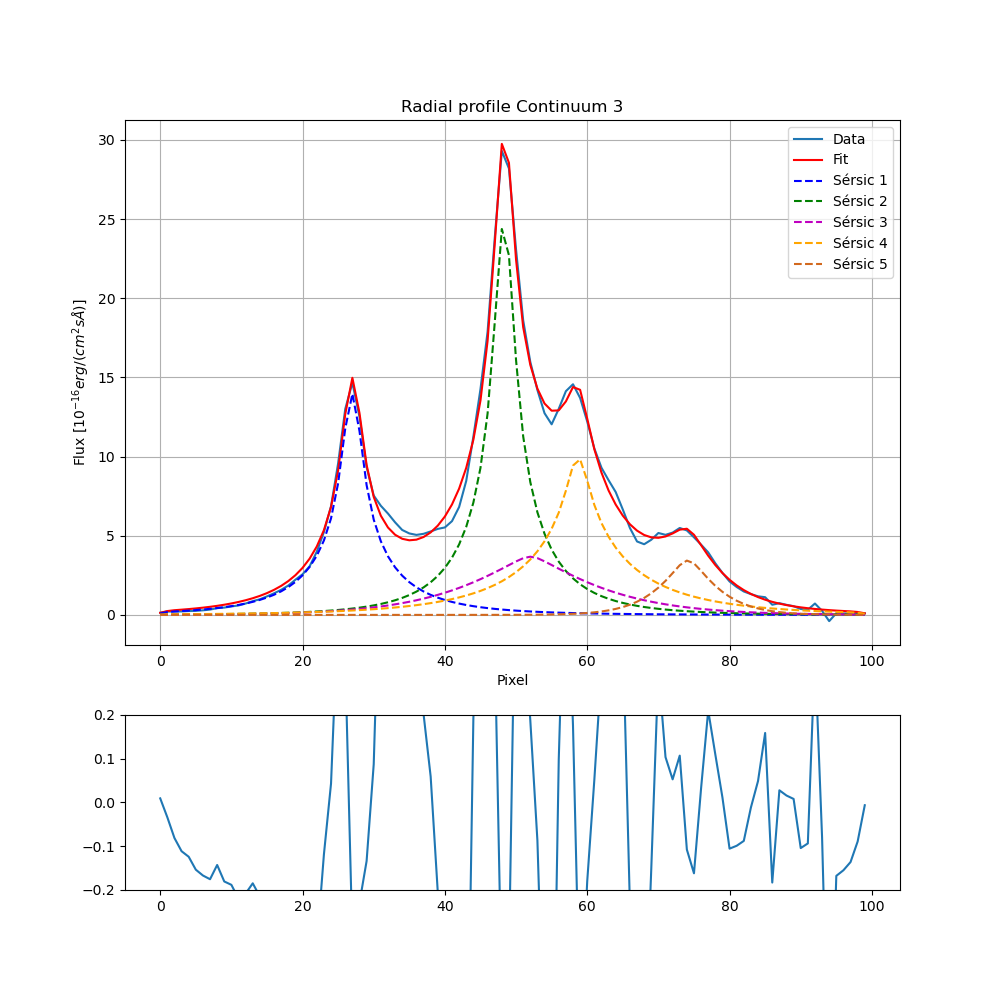

In [106]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [107]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_548\3444057438.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_548\3444057438.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=1.1783, r_e=11.4453, n=1.6745, x_0=26.8738
Sérsic 2: I_e=6.3789, r_e=4.2791, n=0.9200, x_0=48.3634
Sérsic 3: I_e=1.6177, r_e=17.2960, n=0.0560, x_0=47.7377
Sérsic 4: I_e=1.9760, r_e=10.1629, n=1.0612, x_0=58.0556
Sérsic 5: I_e=1.2696, r_e=9.0560, n=0.8465, x_0=73.3760
[0.17787689 0.88981392 0.12413464 0.166234   1.42961717 0.77252191
 0.176837   0.14343116 1.77138843 2.09768156 0.04441324 0.6265578
 0.88576795 5.55636987 0.31480886 0.35415269 0.23244798 1.34325772
 0.07795531 0.49287294]
4.520815088010072


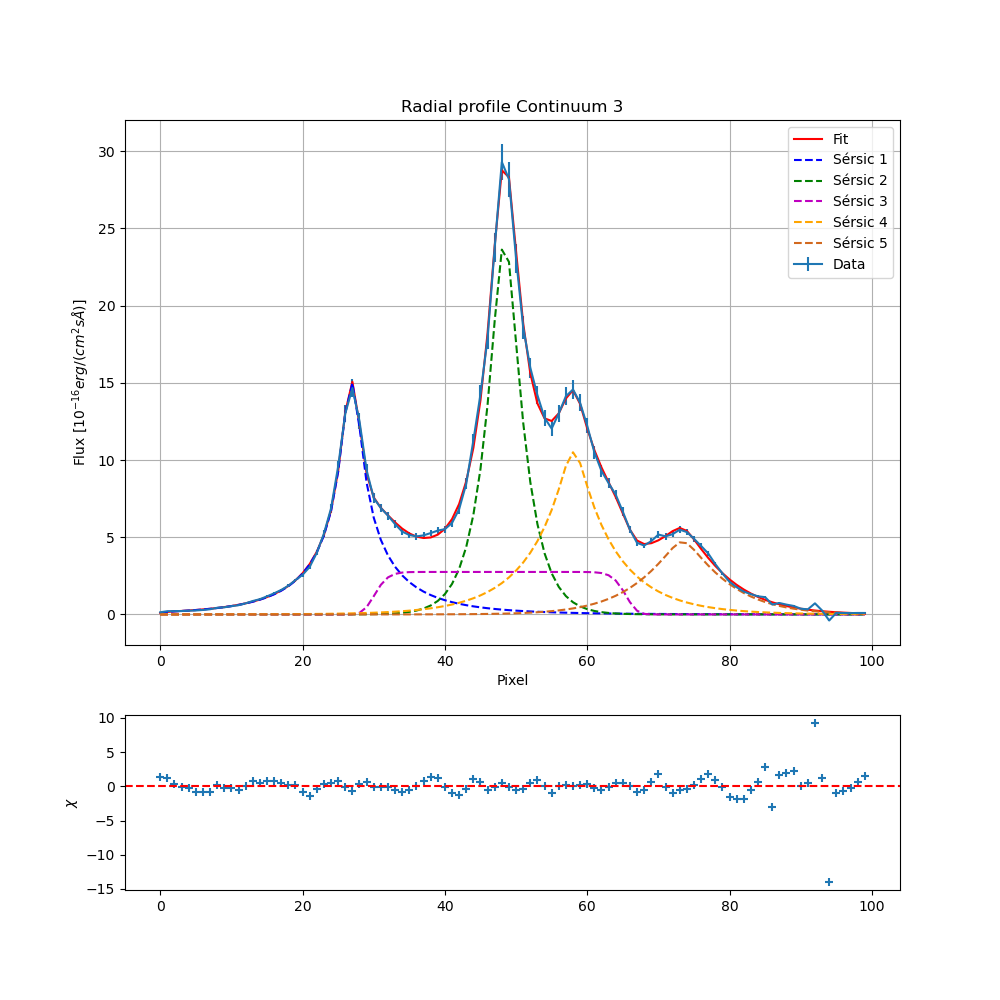

In [108]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [109]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

## Halpha and continuum

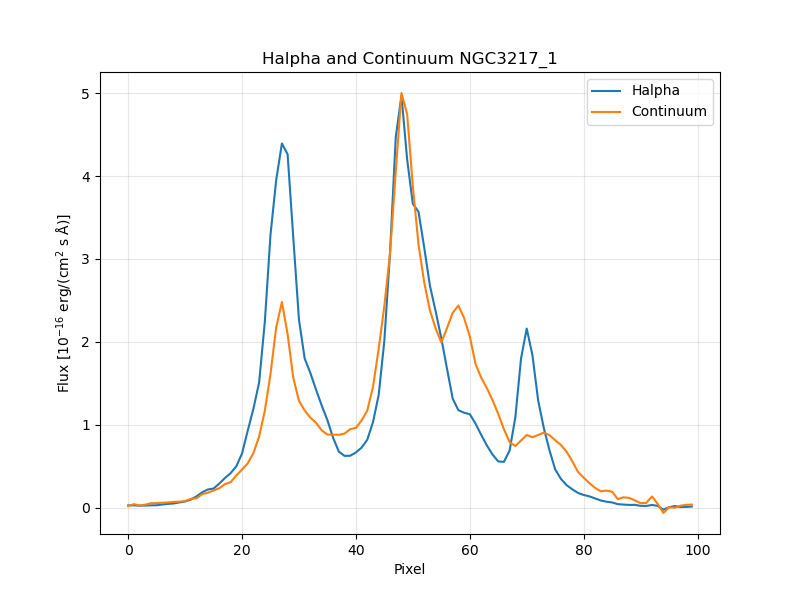

In [61]:
mask_continuum_3 = (wv > 6550)*(wv < 6600)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum NGC3217_1')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_NGC3217_1')